### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

### Load dataset

In [2]:
df = pd.read_csv("Travel.csv")

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [6]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [7]:
df.keys()

Index(['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier',
       'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar',
       'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore',
       'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='object')

### target (y) and features (X)

In [3]:
# ProdTaken is the label we want to predict (0/1)
y = df["ProdTaken"]

# CustomerID is just an ID, not useful for prediction
X = df.drop(columns=["ProdTaken", "CustomerID"])

In [4]:
## Separate numeric vs categorical columns


num_cols = X.select_dtypes(include=["number"]).columns
cat_cols = X.select_dtypes(exclude=["number"]).columns

### Preprocessing

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [9]:
# Numeric: fill missing values using median

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

In [ ]:
# Categorical: fill missing values using most frequent value,
# then convert categories to numbers using OneHotEncoding


categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [12]:
from sklearn.compose import ColumnTransformer

In [13]:
# Combine both preprocessing parts

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

### Train/Test split

In [15]:

from sklearn.model_selection import train_test_split

In [16]:
# stratify=y keeps class ratio (0/1) similar in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Decision Tree

In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
# limit depth to reduce overfitting
# require at least 10 samples in a leaf


dt_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5,          # limit depth to reduce overfitting
        min_samples_leaf=10   # require at least 10 samples in a leaf
    ))
])

###  Random Forest 

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
 # number of trees
 # use all CPU cores
 
rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
        n_estimators=300,    
        min_samples_leaf=5,
        n_jobs=-1           
    ))
])

In [22]:
 #Train 
 
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting',
       'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips',
       'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'NumberOfChildrenVisiting', 'MonthlyIncome'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(min_samples_leaf=5, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

### Predict

In [23]:
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [25]:

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Decision Tree Accuracy: 0.8394683026584867
Random Forest Accuracy: 0.8619631901840491


In [26]:
print("\nDecision Tree Confusion Matrix:\n", confusion_matrix(y_test, dt_pred))
print("\nRandom Forest Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))


Decision Tree Confusion Matrix:
 [[768  26]
 [131  53]]

Random Forest Confusion Matrix:
 [[789   5]
 [130  54]]


In [27]:
print("\nDecision Tree Report:\n", classification_report(y_test, dt_pred))
print("\nRandom Forest Report:\n", classification_report(y_test, rf_pred))


Decision Tree Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91       794
           1       0.67      0.29      0.40       184

    accuracy                           0.84       978
   macro avg       0.76      0.63      0.66       978
weighted avg       0.82      0.84      0.81       978


Random Forest Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92       794
           1       0.92      0.29      0.44       184

    accuracy                           0.86       978
   macro avg       0.89      0.64      0.68       978
weighted avg       0.87      0.86      0.83       978



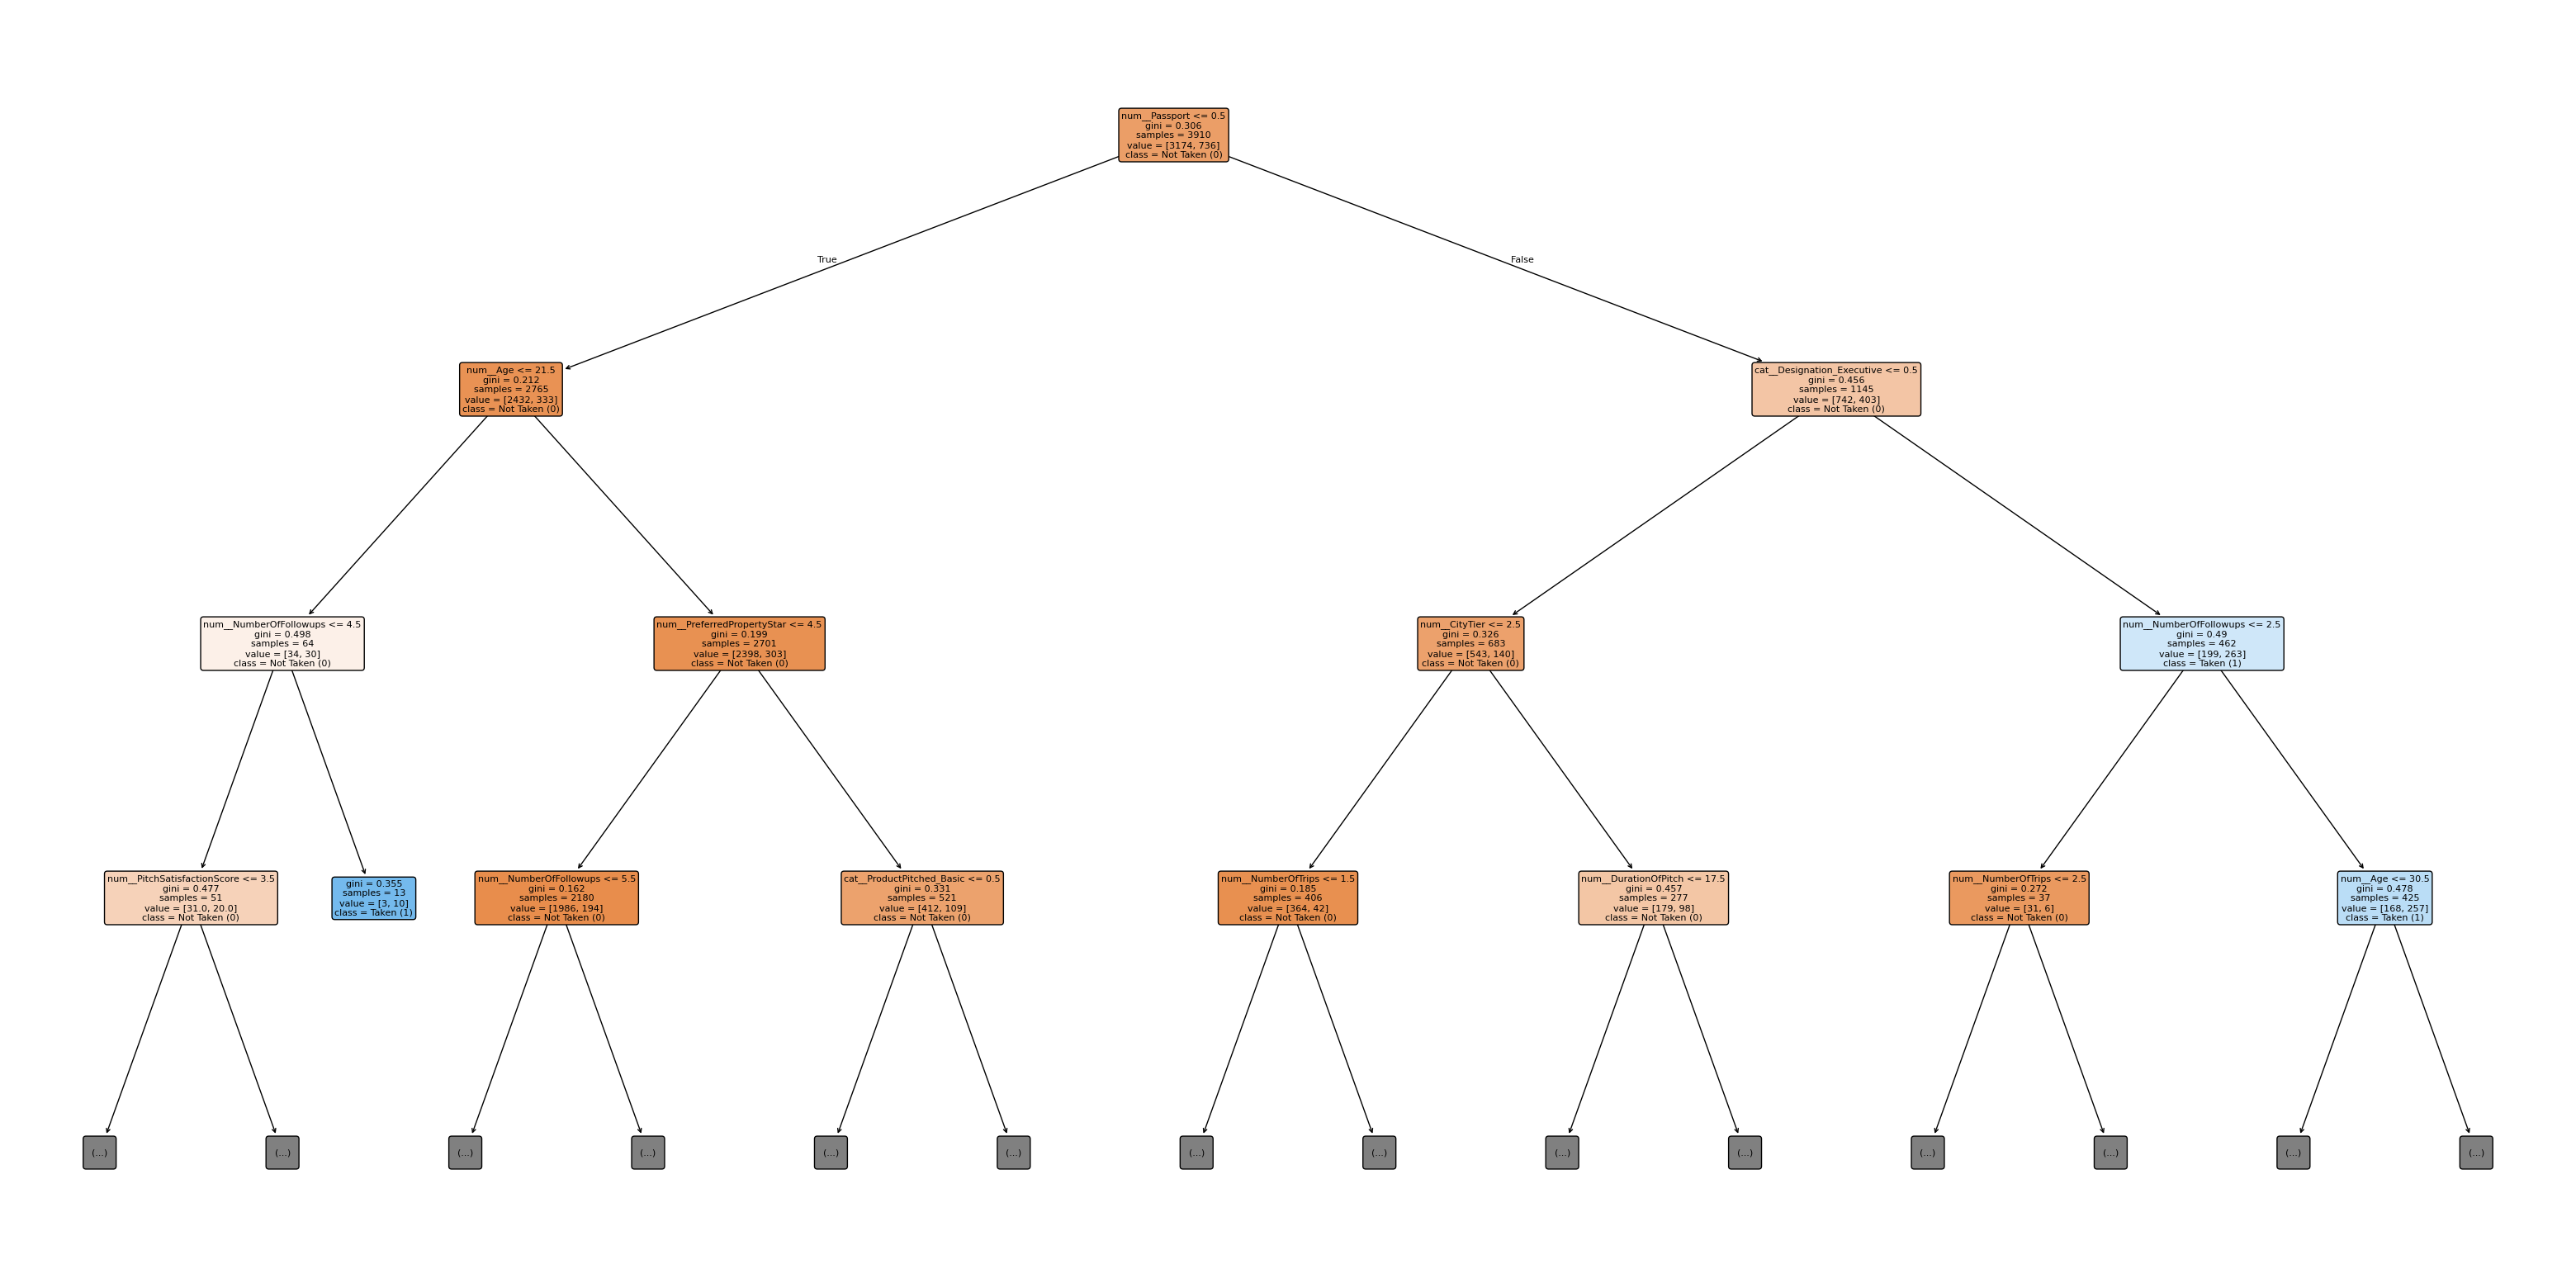

In [33]:
from sklearn import tree

# 1) Take the trained decision tree from pipeline
dtc = dt_model.named_steps["model"]

# 2) Take the fitted preprocessor (it knows the final encoded column names)
pre = dt_model.named_steps["preprocess"]

# 3) Get final feature names after OneHotEncoding
feature_names = pre.get_feature_names_out()

# 4) Plot
plt.figure(figsize=(40, 20))
tree.plot_tree(
    dtc,
    feature_names=feature_names,
    class_names=["Not Taken (0)", "Taken (1)"],
    filled=True,
    rounded=True,
    max_depth=3,      
    fontsize=8
)
plt.show()

